![imagen](Water.jpg)

# Introduction

The objective of this notebook is to apply decision tree-based classification techniques to predict water quality and determine whether a water sample is suitable for human consumption, supporting decision-making for granting consumption permits.

Throughout this exercise, the following tasks will be addressed:

1. Data Loading, Exploration and Visualization: Load the dataset, handle missing values and perform exploratory analysis to identify data quality issues such as missing values and duplicates.

2. Data Preparation: Clean and preprocess the data for the classification algorithm.

3. Decision Tree Modeling: Build a decision tree classifier using GridSearchCV with the following search space:
   - `criterion`: ['gini', 'entropy']
   - `max_depth`: [4, 6, 8, 10, 12]
   - `min_samples_split`: [3, 4, 5]
   - `class_weight = 'balanced'`

4. Model Evaluation: Evaluate the model using recall and precision metrics for each class.

5. Model Interpretation:
   - Identify the most significant variables
   - Extract decision rules (depth = 3) to determine when water is not suitable for consumption

# 1. Import libraries

In [26]:
# Data handling
import pandas as pd

# To prepare
from sklearn.preprocessing import LabelEncoder

# To create the decision tree
from sklearn.tree import DecisionTreeClassifier 

# To split the dataset into training and test sets
from sklearn.model_selection import train_test_split

# To evaluate the model
from sklearn.metrics import accuracy_score

# For performance reporting using ranking metrics 
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay

# For hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# For cross-validation
from sklearn.model_selection import KFold 

# Visualization libraries
import matplotlib.pyplot as plt
from sklearn import tree

from ydata_profiling import ProfileReport

# 2. Load data

In [2]:
data=pd.read_csv('datos_proyecto_modulo4.csv', sep=',', na_values=['?'],encoding = 'utf-8')

In [3]:
data.shape

(3276, 10)

In [4]:
data.head()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
0,NaN,204.89,20791.32,7.30,368.52,564.31,10.38,86.99,2.96,NO
1,3.72,129.42,18630.06,6.64,NaN,592.89,15.18,56.33,4.50,NO
2,8.10,224.24,19909.54,9.28,NaN,418.61,16.87,66.42,3.06,NO
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,NO
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,NO


In [5]:
data.dtypes

pH                  float64
Dureza              float64
Sólidos             float64
Cloraminas          float64
Sulfatos            float64
Conductividad       float64
Carbono_orgánico    float64
Trihalometanos      float64
Turbidez            float64
Potabilidad          object
dtype: object

# 3. EDA

In [6]:
profile = ProfileReport(
    data, 
    title="Analysis Report - Dataset Data",
    explorative=True  
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 179.30it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# 4. Data preparation

In [7]:
data_t = data
data_t=data_t.dropna()

In [8]:
data_t.shape

(2011, 10)

In [9]:
data_t.head()

,pH,Dureza,Sólidos,Cloraminas,Sulfatos,Conductividad,Carbono_orgánico,Trihalometanos,Turbidez,Potabilidad
3,8.32,214.37,22018.42,8.06,356.89,363.27,18.44,100.34,4.63,NO
4,9.09,181.10,17978.99,6.55,310.14,398.41,11.56,32.00,4.08,NO
5,5.58,188.31,28748.69,7.54,326.68,280.47,8.40,54.92,2.56,NO
6,10.22,248.07,28749.72,7.51,393.66,283.65,13.79,84.60,2.67,NO
7,8.64,203.36,13672.09,4.56,303.31,474.61,12.36,62.80,4.40,NO


In [10]:
data_t['Potabilidad'].value_counts()

Potabilidad
NO    1200
SI     811
Name: count, dtype: int64

The dataset is not balanced; you must use class_weight=‘balanced’.

# 5. Model Building

In [11]:
Y=data_t['Potabilidad']
X=data_t.drop(['Potabilidad'], axis=1)

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [13]:
partitions = KFold(n_splits=10, shuffle=True, random_state = 0)

In [14]:
param_grid = {'criterion':['gini', 'entropy'],'max_depth':[4,6,8,10,12],'min_samples_split':[3, 4, 5]}

In [15]:
Tree = DecisionTreeClassifier(class_weight='balanced', random_state=0)

In [17]:
best_model = GridSearchCV(Tree, param_grid, cv=partitions)
best_model.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [4, 6, ...], 'min_samples_split': [3, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramet

In [18]:
best_model.best_params_

{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 4}

In [19]:
final_model = best_model.best_estimator_

y_pred = final_model.predict(X_test)
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

          NO       0.71      0.58      0.64       252
          SI       0.46      0.61      0.53       151

    accuracy                           0.59       403
   macro avg       0.59      0.59      0.58       403
weighted avg       0.62      0.59      0.60       403



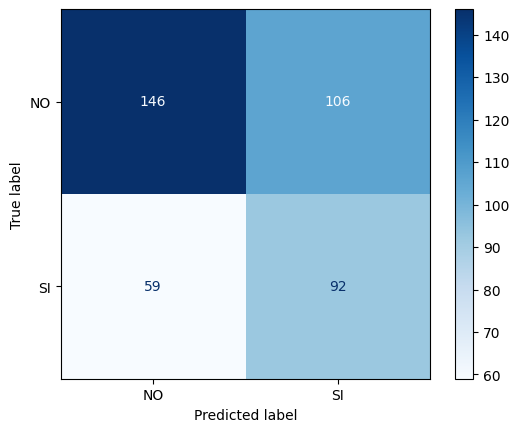

In [22]:
%matplotlib inline
ConfusionMatrixDisplay.from_estimator(final_model, X_test, Y_test, cmap='Blues')

In [23]:
importance = final_model.feature_importances_
importance

array([0.21569214, 0.12172624, 0.12243164, 0.14660628, 0.18739184,
       0.04162741, 0.06006065, 0.03335173, 0.07111207])

In [24]:
attribute_importance = pd.DataFrame(data={"Attribute": X_train.columns,"Importance": importance})
attribute_importance = attribute_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)
attribute_importance

,Attribute,Importance
0,pH,0.215692
1,Sulfatos,0.187392
2,Cloraminas,0.146606
3,Sólidos,0.122432
4,Dureza,0.121726
5,Turbidez,0.071112
6,Carbono_orgánico,0.060061
7,Conductividad,0.041627
8,Trihalometanos,0.033352


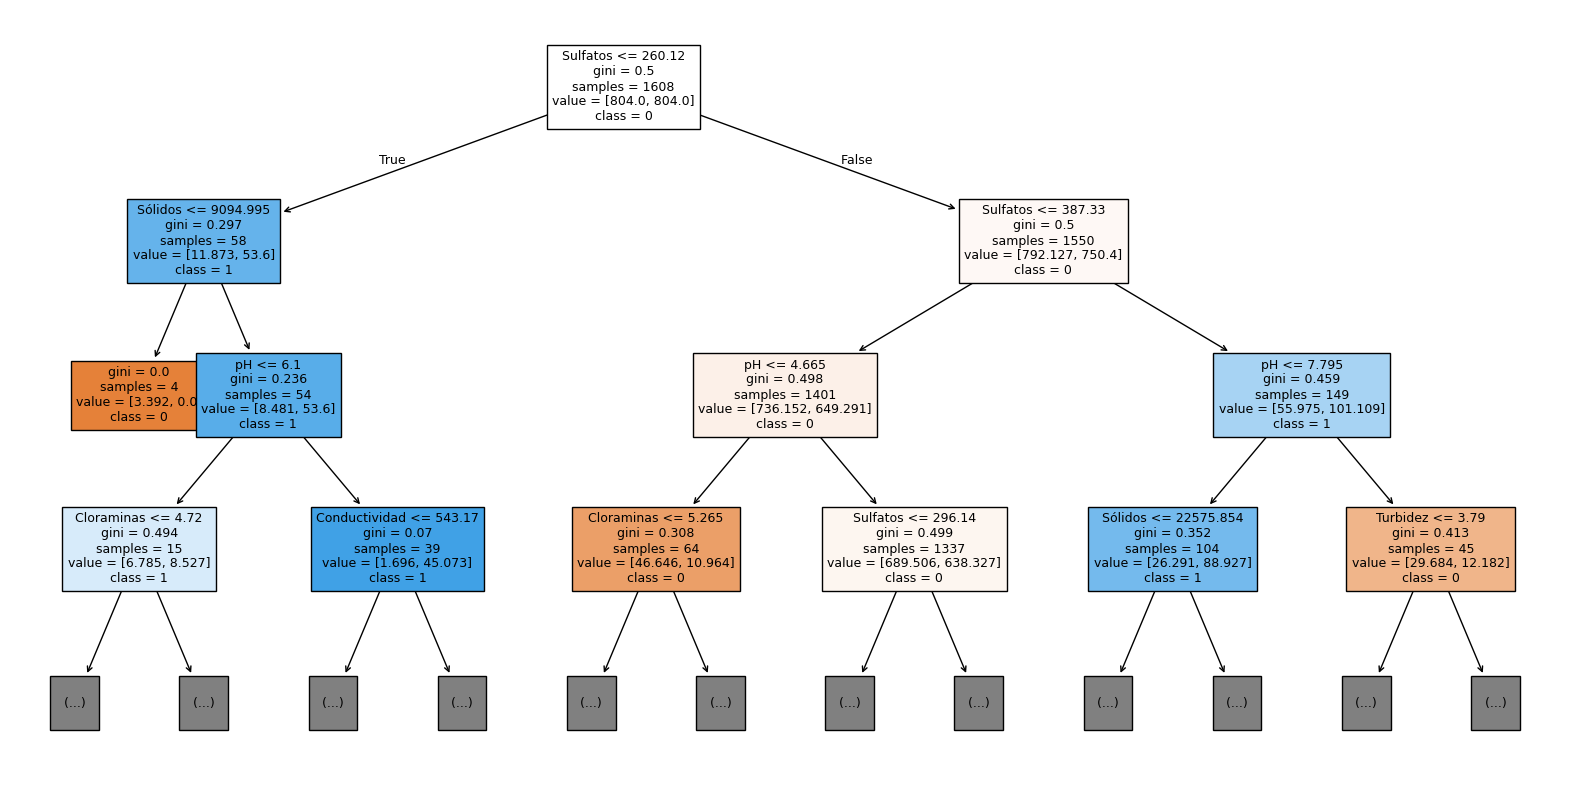

In [27]:
%matplotlib inline
fig = plt.figure(figsize=(20,10))
_ = tree.plot_tree(final_model, max_depth=3, feature_names=X.columns, class_names=["0", "1"], filled=True, fontsize=9)
plt.show()

# 6. Results

The best model achieved the following metrics on the test set with parameters: `criterion='gini'`, `max_depth=10`, `min_samples_split=4`.

Recall is the most important metric. It measures the proportion of water samples that are actually safe that the model correctly identifies. Failing to identify safe drinking water could lead to unnecessary restrictions on access to water. However, the opposite error could result in unsafe water being classified as safe, which would pose a health risk.

The current model shows:
- Recall for “YES”: 61% of suitable samples correctly identified
- Precision for “NO”: 71% of water predicted as unsuitable is actually unsuitable
- Overall accuracy: 59%

The model's performance is moderate (59% accuracy) and could be improved. It is recommended that this be done before the model is implemented for high-stakes decision-making.